# TinyChirp SincNet-Time TensorFlow

Train a 1D CNN with a SincNet-style learnable frontend directly on raw audio waveforms, export an int8 TFLite model, and write a Rust `audio_sample.rs` file.

This mirrors `building_tensorflow/cnn_time.ipynb` but replaces the first convolutional layer with a custom Sinc-like frontend whose learned filters are later baked into a standard `Conv1D` layer for inference.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import tensorflow as tf

from utils import (
    TARGET_AUDIO_LEN_TIME,
    SAMPLE_RATE,
    get_paths,
    configure_tf_runtime,
    set_global_seed,
    make_time_datasets,
    build_representative_batches,
    export_keras_model_to_int8_tflite,
)

configure_tf_runtime()
set_global_seed()

MODEL_STEM = "sincnet_real_multilayer_tf"
paths = get_paths(MODEL_STEM)
OUT_TFLITE = paths.out_tflite
BATCH_SIZE = 32


2026-04-20 09:36:05.523919: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-20 09:36:05.533153: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-20 09:36:05.546646: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-20 09:36:05.546676: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-20 09:36:05.555189: I tensorflow/core/platform/cpu_feature_gua

In [3]:
train_ds, val_ds, test_ds, label_names = make_time_datasets()
num_labels = len(label_names)
print("Classes:", label_names)

Found 11292 files belonging to 2 classes.
Found 1380 files belonging to 2 classes.
Found 1393 files belonging to 2 classes.


2026-04-20 09:36:09.113730: I tensorflow_io/core/kernels/cpu_check.cc:128] Your CPU supports instructions that this TensorFlow IO binary was not compiled to use: SSE3 SSE4.1 SSE4.2 AVX AVX2 FMA


Classes: ['non_target' 'target']


## SincNet-style learnable frontend

We define a simplified SincNet-style learnable filterbank as a custom Keras layer that operates directly on the raw waveform. The layer maintains trainable parameters that are passed through a `sin` nonlinearity to produce filters, which are then applied via a 1D convolution.

In [4]:
import tensorflow as tf
import numpy as np
import math
from utils import get_flops_native

class SincnetConv(tf.keras.layers.Layer):
    def __init__(self, num_filters: int, kernel_size: int, stride: int, sample_rate: int = 16000, **kwargs):
        super().__init__(**kwargs)
        self.num_filters = num_filters
        self.stride = stride
        self.sample_rate = sample_rate
        
        # SincNet requires an odd kernel size for symmetric filters
        self.kernel_size = kernel_size if kernel_size % 2 != 0 else kernel_size + 1

    def build(self, input_shape):
        # 1. Initialize frequencies on the Mel scale
        mel_min = 0.0
        mel_max = self._hz_to_mel(self.sample_rate / 2.0)
        mel_points = np.linspace(mel_min, mel_max, self.num_filters + 1)
        hz_points = self._mel_to_hz(mel_points)
        
        # Normalize frequencies by sample rate (so Nyquist is 0.5)
        f1_init = hz_points[:-1] / self.sample_rate
        band_init = np.diff(hz_points) / self.sample_rate

        # 2. Trainable parameters: low cutoff (f1) and bandwidth (band)
        self.f1 = self.add_weight(
            name='f1',
            shape=(self.num_filters,),
            initializer=tf.keras.initializers.Constant(f1_init),
            trainable=True
        )
        self.band = self.add_weight(
            name='band',
            shape=(self.num_filters,),
            initializer=tf.keras.initializers.Constant(band_init),
            trainable=True
        )

        # 3. Static time grid and Hamming window
        t = np.linspace(-(self.kernel_size // 2), self.kernel_size // 2, self.kernel_size)
        self.t = tf.constant(t, dtype=tf.float32)
        
        window = 0.54 - 0.46 * np.cos(2 * math.pi * np.arange(self.kernel_size) / (self.kernel_size - 1))
        self.window = tf.constant(window, dtype=tf.float32)

    def get_filters(self) -> tf.Tensor:
        # Abs ensures frequencies stay positive
        f1_safe = tf.math.abs(self.f1)
        f2_safe = f1_safe + tf.math.abs(self.band)
        
        f1_mat = tf.reshape(f1_safe, (1, -1))
        f2_mat = tf.reshape(f2_safe, (1, -1))
        t_mat = tf.reshape(self.t, (-1, 1))
        
        # Equation: [sin(2*pi*f2*t) - sin(2*pi*f1*t)] / (pi * t)
        pi_t = math.pi * t_mat
        
        # Prevent division by zero at t=0 by substituting 1.0 (we overwrite the center later)
        denom = tf.where(t_mat == 0.0, 1.0, pi_t)
        
        filters = (tf.math.sin(2.0 * math.pi * f2_mat * t_mat) - 
                   tf.math.sin(2.0 * math.pi * f1_mat * t_mat)) / denom
                   
        # The limit of the function as t approaches 0 is 2(f2 - f1)
        center_values = 2.0 * (f2_mat - f1_mat)
        
        # Inject the mathematical limit into the center index (t=0)
        mask = tf.cast(t_mat == 0.0, tf.float32)
        filters = filters * (1.0 - mask) + center_values * mask
        
        # Apply Hamming Window
        filters = filters * tf.reshape(self.window, (-1, 1))
        
        # Return standard shape: (kernel_size, in_channels, out_channels)
        return tf.reshape(filters, (self.kernel_size, 1, self.num_filters))

    def call(self, inputs: tf.Tensor) -> tf.Tensor:
        return tf.nn.conv1d(inputs, self.get_filters(), stride=self.stride, padding="VALID")

    def export_to_conv1d(self, name="baked_sinc_conv") -> tf.keras.layers.Conv1D:
        """Bakes the dynamic Sinc filters into a static, MicroFlow-ready Conv1D."""
        baked_weights = self.get_filters().numpy()

        conv_layer = tf.keras.layers.Conv1D(
            filters=self.num_filters,
            kernel_size=self.kernel_size,
            strides=self.stride,
            padding="valid",
            use_bias=False,
            name=name
        )

        conv_layer.build(input_shape=(None, None, 1))
        conv_layer.set_weights([baked_weights])
        return conv_layer

    def get_config(self):
        config = super().get_config()
        config.update({
            "num_filters": self.num_filters,
            "kernel_size": self.kernel_size,
            "stride": self.stride,
            "sample_rate": self.sample_rate,
        })
        return config

    # Mel-Scale DSP Helpers
    def _hz_to_mel(self, hz):
        return 2595.0 * np.log10(1.0 + hz / 700.0)
    
    def _mel_to_hz(self, mel):
        return 700.0 * (10.0**(mel / 2595.0) - 1.0)

In [5]:
SINCNET_FILTERS = 48
SINCNET_STRIDE = 16
SINCNET_KERNEL_SIZE = 32

CONV_FILTERS = 16
CONV_FILTER_SIZE = 5
CONV_STRIDE = 1

DENSE_HIDDEN = 64


def build_training_model(num_labels: int) -> tf.keras.Model:
    inputs = tf.keras.Input(shape=(TARGET_AUDIO_LEN_TIME, 1))
    
    # Use the real SincNet!
    x = SincnetConv(
        num_filters=SINCNET_FILTERS, 
        kernel_size=SINCNET_KERNEL_SIZE, 
        stride=SINCNET_STRIDE, 
        sample_rate=SAMPLE_RATE,
        name="sincnet_convolution"
    )(inputs)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.AveragePooling1D(pool_size=4, name="envelope_pool")(x)
    
    x = tf.keras.layers.Conv1D(
        filters=CONV_FILTERS, 
        kernel_size=CONV_FILTER_SIZE, 
        strides=CONV_STRIDE, 
        padding="same", 
        name="temporal_conv_1"
    )(x)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.AveragePooling1D(pool_size=4, name="temporal_pool_1")(x)
    
    x = tf.keras.layers.Conv1D(
        filters=CONV_FILTERS, 
        kernel_size=CONV_FILTER_SIZE, 
        strides=CONV_STRIDE, 
        padding="same", 
        name="temporal_conv_2"
    )(x)
    x = tf.keras.layers.ReLU()(x)
    
    # GlobalAveragePooling1D maps to MEAN in TFLite which microflow doesn't support.
    # AveragePooling1D maps to AVERAGE_POOL_2D — cover the full time dimension instead.
    x = tf.keras.layers.AveragePooling1D(pool_size=x.shape[1], padding="valid", name="final_pool")(x)
    x = tf.keras.layers.Flatten(name="flatten")(x)
    
    x = tf.keras.layers.Dense(DENSE_HIDDEN, activation="relu", name="dense_hidden")(x)
    outputs = tf.keras.layers.Dense(num_labels, activation=None, name="dense_logits")(x)
    
    return tf.keras.Model(inputs, outputs, name="sincnet_training")

training_model = build_training_model(num_labels)
training_model.summary()

flops = get_flops_native(training_model, batch_size=1)
print(f"Total FLOPs: {flops}")

Model: "sincnet_training"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 47872, 1)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sincnet_convolution             │ (None, 2990, 48)       │            96 │
│ (SincnetConv)                   │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 2990, 48)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ envelope_pool                   │ (None, 747, 48)        │             0 │
│ (AveragePooling1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ temporal_conv_1 (Conv1D)        │ (None, 747, 16)        │         3,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 747, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ temporal_pool_1                 │ (None, 186, 16)        │             0 │
│ (AveragePooling1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ temporal_conv_2 (Conv1D)        │ (None, 186, 16)        │         1,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 186, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ final_pool (AveragePooling1D)   │ (None, 1, 16)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_logits (Dense)            │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,466 (25.26 KB)

 Trainable params: 6,466 (25.26 KB)

 Non-trainable params: 0 (0.00 B)

Total FLOPs: 15874086


/home/nathan/Documents/tiny-chirp-microflow/building_tensorflow/.venv/lib/python3.11/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(1, 47872, 1))']
  warnings.warn(msg)
2026-04-20 09:36:10.014970: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-20 09:36:10.015922: I tensorflow/core/grappler/devices.cc:66] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
2026-04-20 09:36:10.015992: I tensorflow/core/grappler/clusters/single_machine.cc:361] Starting new session
2026-04-20 09:36:10.016360: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUM

In [6]:
from utils import init_wandb, get_callbacks, finish_wandb

training_model.compile(
    optimizer="adam",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)

init_wandb(MODEL_STEM, config={
    "sincnet_num_filters": SINCNET_FILTERS,
    "sincnet_kernel_size": SINCNET_KERNEL_SIZE,
    "sincnet_stride": SINCNET_STRIDE,
    "conv_filters": CONV_FILTERS,
    "conv_filter_size": CONV_FILTER_SIZE,
    "conv_stride": CONV_STRIDE,
    "dense_hidden": DENSE_HIDDEN,
})

history = training_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    validation_steps=44,
    callbacks=get_callbacks(10,5,BATCH_SIZE)
)
finish_wandb()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/nathan/.netrc.
wandb: Currently logged in as: nathan-duboisset (nathan-duboisset-cole-polytechnique) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch 1/100


I0000 00:00:1776670572.733833   33264 service.cc:145] XLA service 0x7c1d44005a40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776670572.733860   33264 service.cc:153]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9
2026-04-20 09:36:12.769005: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-04-20 09:36:12.964361: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 8907


 24/353 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6771 - loss: 0.6796

I0000 00:00:1776670574.708105   33264 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


353/353 ━━━━━━━━━━━━━━━━━━━━ 25s 62ms/step - accuracy: 0.8288 - loss: 0.3547 - val_accuracy: 0.9283 - val_loss: 0.1970
Epoch 2/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 19s 52ms/step - accuracy: 0.9083 - loss: 0.2332 - val_accuracy: 0.9268 - val_loss: 0.1948
Epoch 3/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 19s 53ms/step - accuracy: 0.9193 - loss: 0.2193 - val_accuracy: 0.9326 - val_loss: 0.1818
Epoch 4/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 19s 53ms/step - accuracy: 0.9266 - loss: 0.1950 - val_accuracy: 0.9399 - val_loss: 0.1677
Epoch 5/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 19s 52ms/step - accuracy: 0.9310 - loss: 0.1776 - val_accuracy: 0.9384 - val_loss: 0.1538
Epoch 6/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 19s 53ms/step - accuracy: 0.9371 - loss: 0.1634 - val_accuracy: 0.9399 - val_loss: 0.1434
Epoch 7/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 19s 53ms/step - accuracy: 0.9432 - loss: 0.1493 - val_accuracy: 0.9471 - val_loss: 0.1197
Epoch 8/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 19s 53ms/step - accuracy: 0.9498 - loss: 0.1363 - val_

2026-04-20 09:44:07.325542: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 12255488 bytes after encountering the first element of size 6127744 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


353/353 ━━━━━━━━━━━━━━━━━━━━ 19s 54ms/step - accuracy: 0.9726 - loss: 0.0762 - val_accuracy: 0.9681 - val_loss: 0.0747
Epoch 27/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 19s 52ms/step - accuracy: 0.9733 - loss: 0.0719 - val_accuracy: 0.9710 - val_loss: 0.0781
Epoch 28/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 19s 52ms/step - accuracy: 0.9733 - loss: 0.0727 - val_accuracy: 0.9732 - val_loss: 0.0748
Epoch 29/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 19s 53ms/step - accuracy: 0.9747 - loss: 0.0696 - val_accuracy: 0.9732 - val_loss: 0.0719
Epoch 30/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 19s 53ms/step - accuracy: 0.9766 - loss: 0.0636 - val_accuracy: 0.9754 - val_loss: 0.0685
Epoch 31/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 19s 53ms/step - accuracy: 0.9785 - loss: 0.0603 - val_accuracy: 0.9710 - val_loss: 0.0642
Epoch 32/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 19s 54ms/step - accuracy: 0.9789 - loss: 0.0612 - val_accuracy: 0.9790 - val_loss: 0.0634
Epoch 33/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 19s 53ms/step - accuracy: 0.9787 - loss: 0.0588

batch/accuracy,▁▂▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇█████████████████████
batch/batch_step,▁▁▁▁▁▂▂▂▂▂▂▂▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▅▅▆▆▆▆▆▇▇▇███
batch/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
batch/loss,██▇▅▅▄▄▄▃▄▃▃▂▂▂▂▂▂▂▂▂▁▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/accuracy,▁▄▅▅▆▆▇▇▇▇▇▇▇▇▇█████████████████████████
epoch/epoch,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇█
epoch/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▅▅▅▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/val_accuracy,▁▁▂▂▄▅▅▅▅▅▅▅▅▄▅▆▆▆▆▆▇▇▇█▇▆▇████▇███▇████
epoch/val_loss,█▇▇▅▅▄▄▄▄▄▃▃▃▃▂▂▂▂▂▂▂▁▂▂▁▁▂▁▂▁▁▁▁▁▁▁▁▂▁▁
+6,...


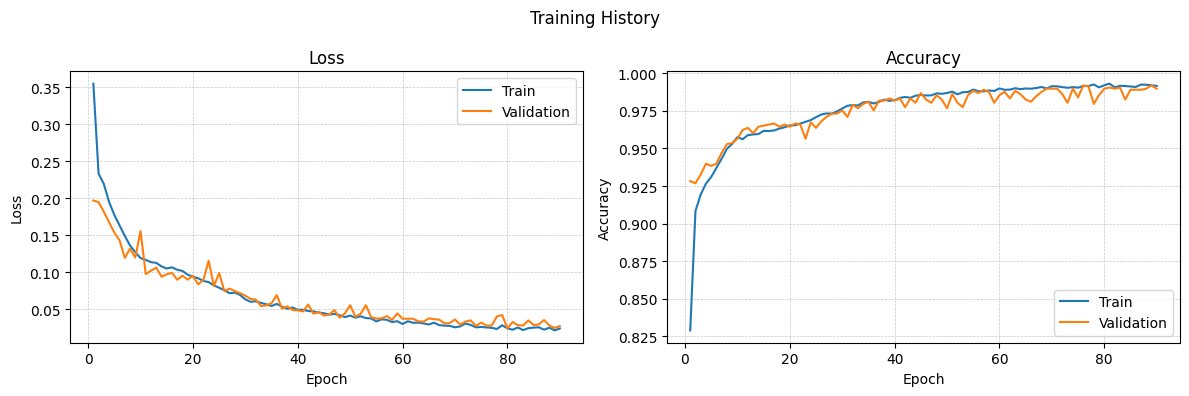

In [7]:
from utils import plot_training_history
plot_training_history(history)

## Make frontend filters into a Conv1D inference model


In [8]:
frontend_layer = training_model.get_layer("sincnet_convolution")
baked_conv_layer = frontend_layer.export_to_conv1d(name="baked_sinc_conv")

infer_inputs = tf.keras.Input(shape=(TARGET_AUDIO_LEN_TIME, 1))
x = baked_conv_layer(infer_inputs)
x = tf.keras.layers.ReLU()(x)
x = training_model.get_layer("envelope_pool")(x)
x = training_model.get_layer("temporal_conv_1")(x)
x = tf.keras.layers.ReLU()(x)
x = training_model.get_layer("temporal_pool_1")(x)
x = training_model.get_layer("temporal_conv_2")(x)
x = tf.keras.layers.ReLU()(x)
x = training_model.get_layer("final_pool")(x)
x = training_model.get_layer("flatten")(x)
x = training_model.get_layer("dense_hidden")(x)
outputs = training_model.get_layer("dense_logits")(x)

inference_model = tf.keras.Model(infer_inputs, outputs, name="sincnet_inference")

for batch_audio, _ in test_ds.take(1):
    logits_train = training_model.predict(batch_audio.numpy(), verbose=0)
    logits_infer = inference_model.predict(batch_audio.numpy(), verbose=0)
    print(f"Max abs diff: {np.max(np.abs(logits_train - logits_infer)):.8f}")

Max abs diff: 0.00000000


2026-04-20 10:05:01.286690: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


## Export quantized TFLite model and Rust audio samples

We now export an int8-quantized TFLite model using the shared helpers from `building_tensorflow.utils`, and regenerate `audio_sample.rs` clips for the TinyChirp Rust runner.

In [9]:
rep_batches = build_representative_batches(test_ds, take=100)

try:
    export_keras_model_to_int8_tflite(inference_model, rep_batches, OUT_TFLITE)
    print(f"Success! Wrote {OUT_TFLITE}")
except Exception as e:
    print(f"TFLite conversion failed: {e}")

Saved artifact at '/tmp/tmpbu6fovng'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(1, 47872, 1), dtype=tf.float32, name=None)
Output Type:
  TensorSpec(shape=(1, 2), dtype=tf.float32, name=None)
Captures:
  136470553990896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136469221397376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136469221395440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136469221398256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136469221397552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136469221398784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136469221399664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136469221399840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136469221400720: TensorSpec(shape=(), dtype=tf.resource, name=None)


2026-04-20 10:05:01.637483: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
W0000 00:00:1776672301.883163   33185 tf_tfl_flatbuffer_helpers.cc:390] Ignored output_format.
W0000 00:00:1776672301.883206   33185 tf_tfl_flatbuffer_helpers.cc:393] Ignored drop_control_dependency.
2026-04-20 10:05:01.892491: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpbu6fovng
2026-04-20 10:05:01.893083: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-20 10:05:01.893092: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpbu6fovng
2026-04-20 10:05:01.898833: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:388] MLIR V1 optimization pass is not enabled
2026-04-20 10:05:01.899553: I tensorflow/cc/saved_model/loader.cc:234] Restoring SavedModel bundle.
2026-04-20 10:05:01.923899: I tensorflow/cc/saved_model/

Success! Wrote /home/nathan/Documents/tiny-chirp-microflow/models/sincnet_real_multilayer_tf.tflite


fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8
2026-04-20 10:05:02.220622: I tensorflow/compiler/mlir/lite/flatbuffer_export.cc:3064] Estimated count of arithmetic ops: 16.005 M  ops, equivalently 8.002 M  MACs


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
2026-04-20 10:05:26.610138: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-04-20 10:05:29.479666: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Model size : 8.4 KB
Est. MFLOPs: 0.545
=== Binary classifier metrics : TEST SET===
Threshold: 0.0195  (best F2 threshold)
Accuracy : 0.9325
Precision: 0.8434
Recall   : 0.9760
F2 score : 0.9462
=== Binary classifier metrics : TRAIN SET===
AUC      : 0.9808


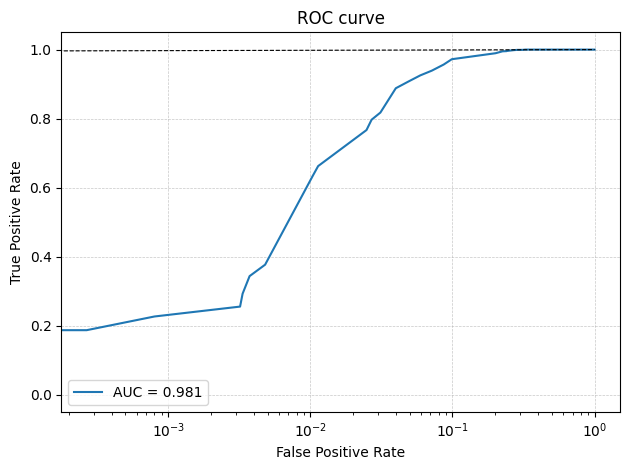

Avg inference: 1.536 ms


In [10]:
from utils import evaluate_tflite_model

train_m, test_m, avg_ms = evaluate_tflite_model(OUT_TFLITE, MODEL_STEM, train_ds, test_ds)
print(f"Avg inference: {avg_ms:.3f} ms")